In [4]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import copy

In [5]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Шум Гаусса

In [6]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

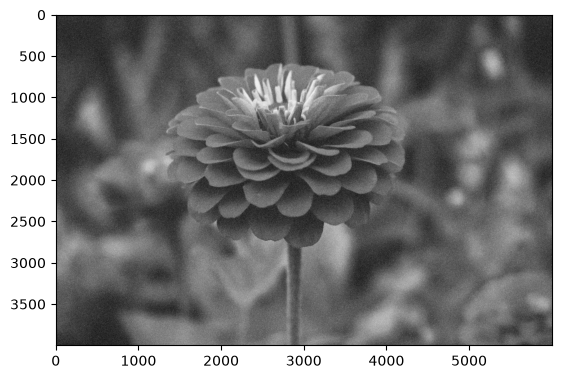

In [7]:
plt.imshow(image_noise_gauss, cmap="gray")

In [8]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim_gauss)

4498.495616958333 0.025890101157439005


# Постоянный шум

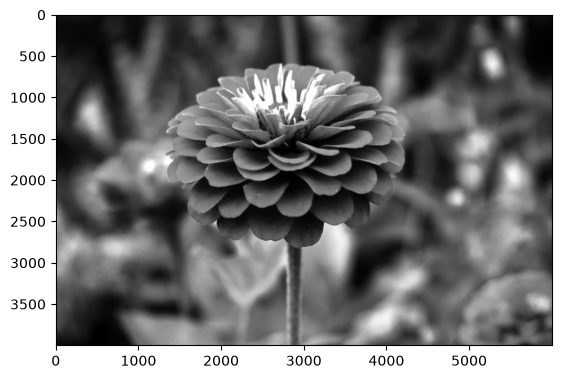

In [14]:
noise = np.random.randint(-100, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)
image_sp = cv2.add(image_sp, 100)
plt.imshow(image_sp, cmap="gray")

In [15]:
plt.show()

In [16]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

9961.981338458334 0.5668588722096451


# Медианный фильтр

In [17]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

844.0684315833333 0.1536194148874991


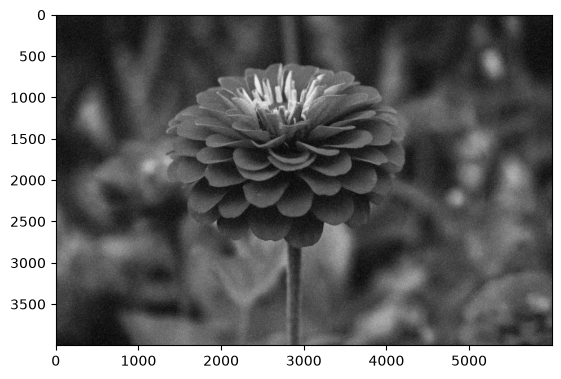

In [18]:
plt.imshow(image_gauss_median, cmap="gray")

In [19]:
image_gauss_median_5 = cv2.medianBlur(image_noise_gauss, 5)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median_5)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median_5, full=True)
print(mse_gauss_median, ssim_gauss_median)

333.2517864166667 0.36576247704714865


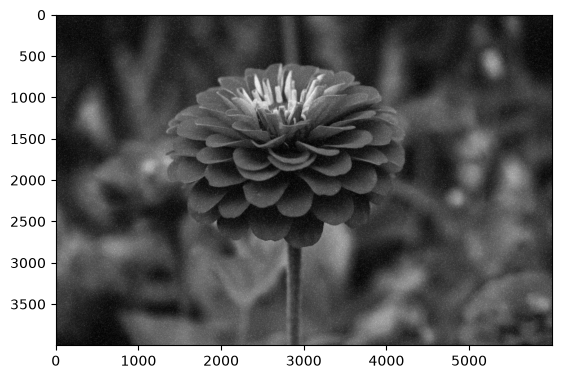

In [20]:
plt.imshow(image_gauss_median_5, cmap="gray")

In [21]:
image_sp_median = cv2.medianBlur(image_sp, 3)
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

9954.9448575 0.5086668635407277


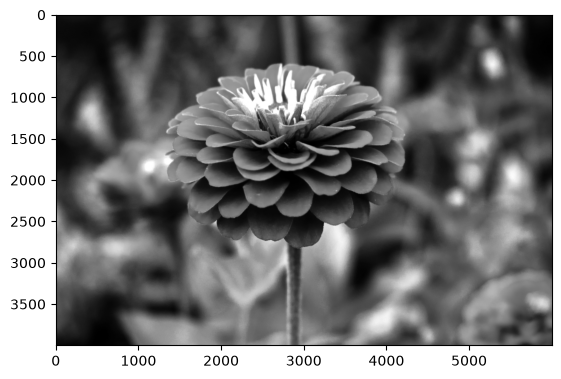

In [22]:
plt.imshow(image_sp_median, cmap="gray")

In [23]:
image_sp_median_5 = cv2.medianBlur(image_sp, 5)
mse_sp_median = mean_squared_error(image_gray, image_sp_median_5)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median_5, full=True)
print(mse_sp_median, ssim_sp_median)

9954.326021875 0.4720633896475803


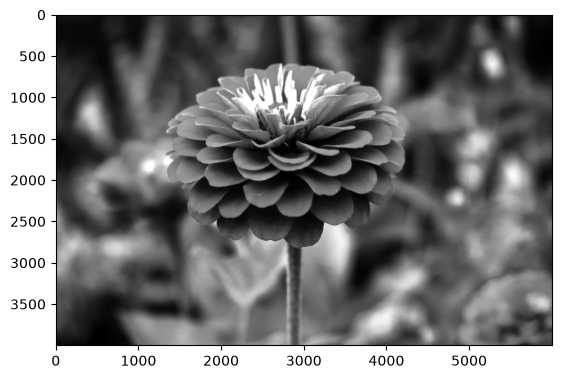

In [24]:
plt.imshow(image_sp_median_5, cmap="gray")

# Фильтр Гаусса

In [25]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (3,3), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1926.513640625 0.14123068983097767


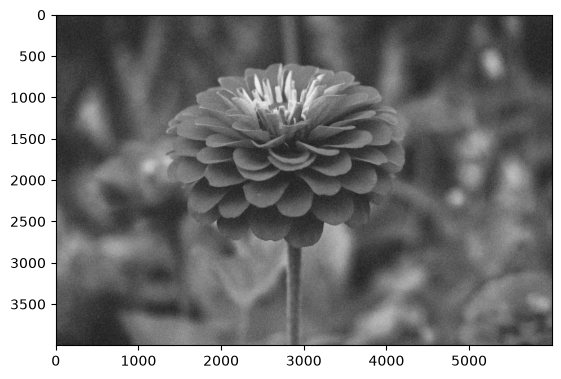

In [26]:
plt.imshow(image_gauss_gauss, cmap="gray")

In [27]:
image_gauss_gauss_5 = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss_5)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss_5, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1729.2054128333334 0.2304045520784348


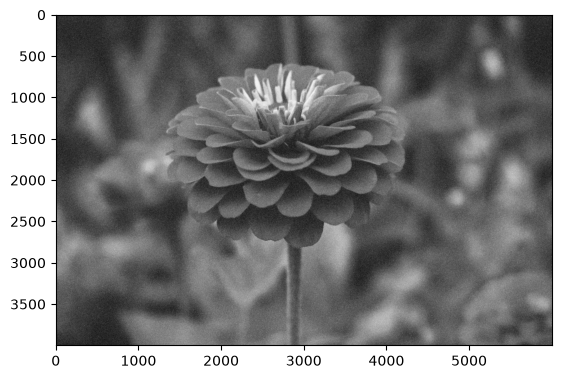

In [28]:
plt.imshow(image_gauss_gauss_5, cmap="gray")

In [29]:
image_sp_gauss = cv2.GaussianBlur(image_sp, (3,3), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

9972.449963 0.5292450305033175


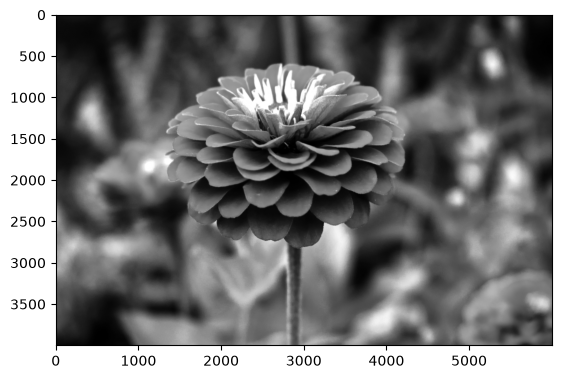

In [30]:
plt.imshow(image_sp_gauss, cmap="gray")

In [31]:
image_sp_gauss_5 = cv2.GaussianBlur(image_sp, (5,5), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss_5)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss_5, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

9969.842997041667 0.5065678886539837


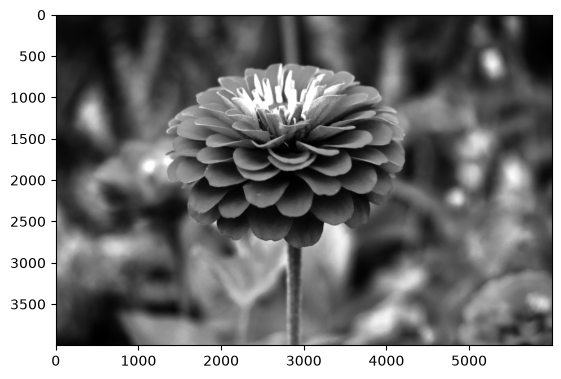

In [32]:
plt.imshow(image_sp_gauss_5, cmap="gray")

# Билатеральный фильтр

In [33]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1786.3903612083334 0.1045069515651392


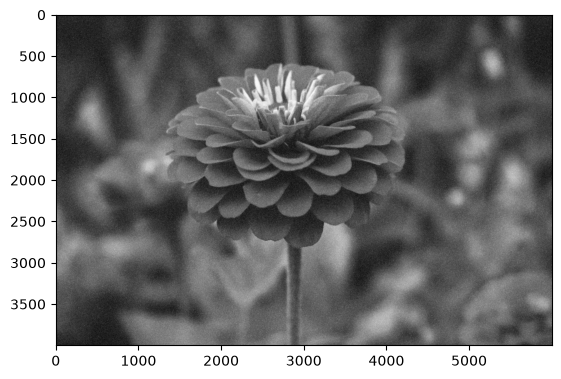

In [34]:
plt.imshow(image_gauss_bilat, cmap="gray")

In [35]:
image_gauss_bilat_150 = cv2.bilateralFilter(image_noise_gauss, 9, 150, 150)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat_150)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat_150, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1362.982392375 0.3525109210916518


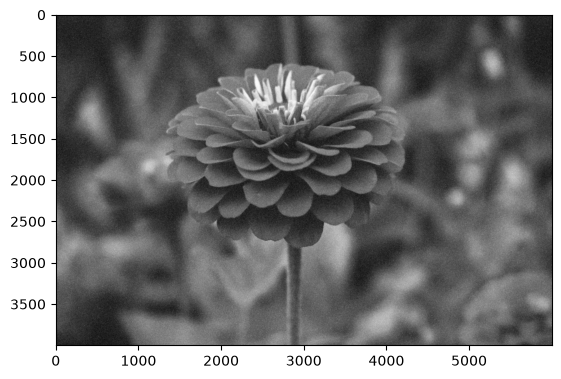

In [36]:
plt.imshow(image_gauss_bilat_150, cmap="gray")

In [37]:
image_sp_bilat = cv2.bilateralFilter(image_sp, 9, 75, 75)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

9973.77256625 0.4723920781507581


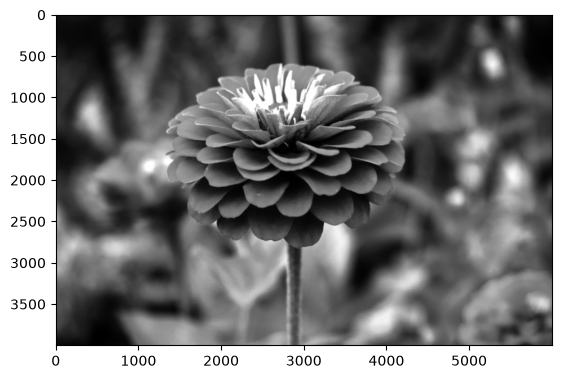

In [38]:
plt.imshow(image_sp_bilat, cmap="gray")

In [39]:
image_sp_bilat_150 = cv2.bilateralFilter(image_sp, 9, 150, 150)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat_150)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat_150, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

9973.972326541667 0.4717197182660385


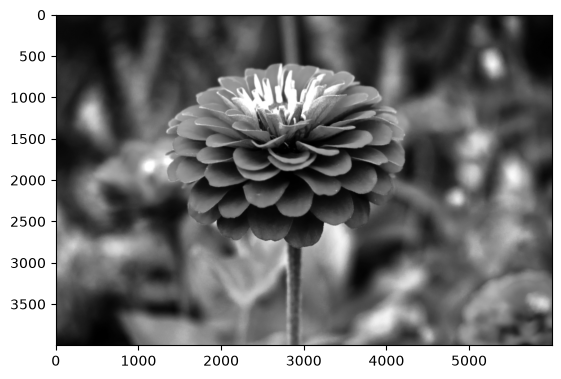

In [40]:
plt.imshow(image_sp_bilat_150, cmap="gray")

# Фильтр нелокальных средних

In [41]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 10)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4498.358609625 0.02608514366593419


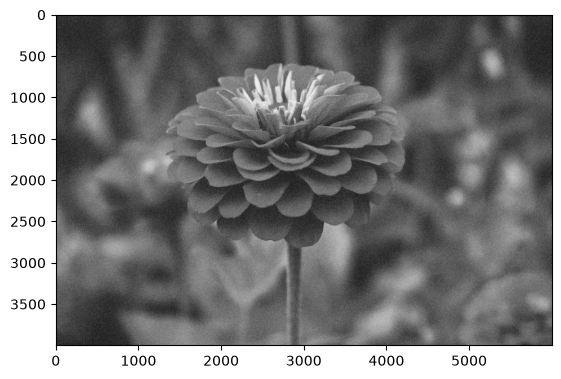

In [42]:
plt.imshow(image_gauss_nlm, cmap="gray")

In [43]:
image_gauss_nlm_20 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm_20)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm_20, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4486.269640875 0.028931002176420983


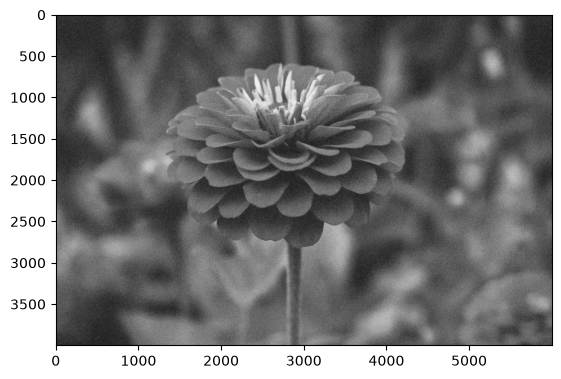

In [44]:
plt.imshow(image_gauss_nlm_20, cmap="gray")

In [45]:
image_sp_nlm = cv2.fastNlMeansDenoising(image_sp, h = 10)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

9970.378650333334 0.4727945873518911


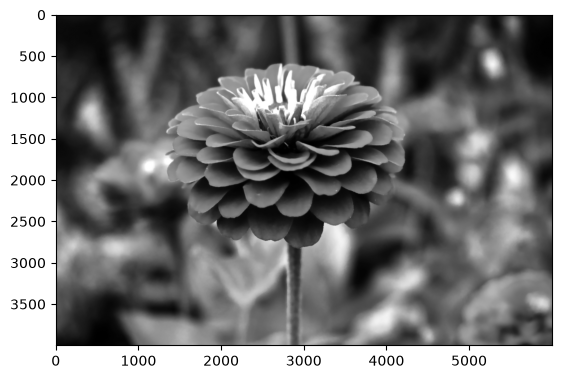

In [46]:
plt.imshow(image_sp_nlm, cmap="gray")

In [47]:
image_sp_nlm_20 = cv2.fastNlMeansDenoising(image_sp, h = 20)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm_20)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm_20, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

9972.702369708333 0.46966847963602726


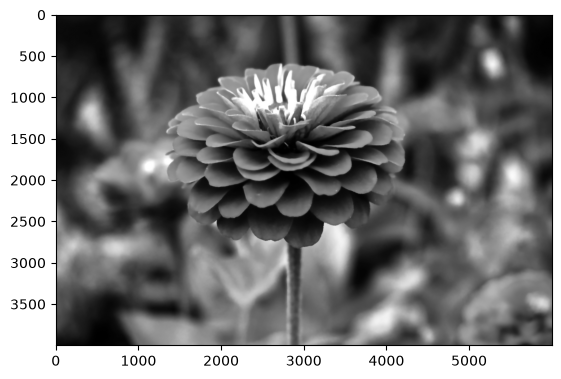

In [48]:
plt.imshow(image_sp_nlm_20, cmap="gray")

# Сравнение фильтров


## Шум Гаусса

| Фильтр | Параметр | MSE ↓ | SSIM ↑ |
|---|---|---|---|
| **Медианный** | 3 | 844.07 | 0.1536 |
| **Медианный** | 5 | **333.25** | **0.3658** |
| Гаусса | 3 | 1926.51 | 0.1412 |
| Гаусса | 5 | 1729.21 | 0.2304 |
| Билатеральный | 9, 75, 75 | 1362.98 | 0.3525 |
| Билатеральный | 9, 150, 150 | 1786.39 | 0.1045 |
| Нелокальных средних | 10 | 4498.36 | 0.0261 |
| Нелокальных средних | 20 | 4486.27 | 0.0289 |

### Лучший для шума Гаусса: Медианный фильтр, параметр 5

## Постоянный шум

| Фильтр | Параметр | MSE ↓ | SSIM ↑ |
|---|---|---|---|
| Медианный | 3 | 9954.94 | 0.5087 |
| **Медианный** | 5 | **9954.33** | 0.4721 |
| **Гаусса** | 3 | 9972.45 | **0.5292** |
| Гаусса | 5 | 9969.84 | 0.5066 |
| Билатеральный | 9, 75, 75 | 9973.77 | 0.4724 |
| Билатеральный | 9, 150, 150 | 9973.97 | 0.4717 |
| Нелокальных средних | 10 | 9970.38 | 0.4728 |
| Нелокальных средних | 20 | 9972.70 | 0.4697 |

### Лучший для постоянного шума

| По критерию | Победитель | Значение |
|---|---|---|
| Минимум MSE | Медианный, параметр 5 | 9954.33 |
| Максимум SSIM | Гаусса, параметр 3 | 0.5292 |
